# Customer Churn & Retention Analysis

## Project Objective

Analyze customer churn patterns to identify the customer segments and factors associated with higher churn, evaluate the business impact of churn, and provide data-driven recommendations to improve customer retention.

In [89]:
## Import libraries for data manipulation, numerical analysis, visualization, and statistical testing 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [90]:
## Load the customer churn dataset into a Pandas DataFrame

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 2. Data Understanding

The dataset contains customer-level information including demographics, services, contract details, payment methods, tenure, monthly charges, total charges, and churn status.

In [91]:
## Check the number of customers and attributes in the dataset

df.shape

(7043, 21)

In [92]:
## Preview the first five records to understand the structure and values of the dataset

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [93]:
# Display all column names to understand the available customer attributes

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [94]:
# Inspect data types, non-null counts, and overall dataset structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Data Cleaning

The dataset was checked for missing values, duplicate records, incorrect data types, and inconsistent categorical values before performing analysis.

In [95]:
# Check whether the dataset contains duplicate customer records

df.duplicated().sum()

np.int64(0)

In [96]:
# Check the least frequent TotalCharges values
df["TotalCharges"].value_counts().tail(10)

TotalCharges
2625.25    1
6886.25    1
1495.1     1
743.3      1
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, dtype: int64

In [97]:
# Inspect TotalCharges values to identify unusual or potentially invalid entries

df["TotalCharges"].value_counts().tail(10)

TotalCharges
2625.25    1
6886.25    1
1495.1     1
743.3      1
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, dtype: int64

In [98]:
# Convert TotalCharges from text to numeric values and treat invalid entries as missing values

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [99]:
# Check how many missing values were created after converting TotalCharges to numeric

df["TotalCharges"].isna().sum()

np.int64(11)

In [100]:
# Examine the customer records where TotalCharges is missing

df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [101]:
# Replace missing TotalCharges values with zero because these customers have zero months of tenure

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [102]:
# Verify that TotalCharges no longer contains missing values

df["TotalCharges"].isna().sum()

np.int64(0)

In [103]:
# Confirm that TotalCharges is now stored as a numeric column

df["TotalCharges"].dtype

dtype('float64')

In [104]:
# Check for missing values across all columns after data cleaning

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [105]:
# Inspect unique values in categorical columns to identify categories and possible inconsistencies

for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

/var/folders/cs/bx35qn657bjb2sh3bhnt2kgc0000gn/T/ipykernel_1949/625811045.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [106]:
# Check categorical columns for values containing only whitespace

for col in df.select_dtypes(include="object").columns:
    spaces = df[col].astype(str).str.contains(r"^\s|\s$", regex=True).sum()
    if spaces > 0:
        print(col, spaces)

/var/folders/cs/bx35qn657bjb2sh3bhnt2kgc0000gn/T/ipykernel_1949/2267711650.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


## 4. Exploratory Data Analysis (EDA)

Explore customer churn patterns across customer demographics, services, contracts, tenure, payment methods, and monthly charges.

In [107]:
#EDA 

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [108]:
#churn rate.
churn_rate = (df["Churn"] == "Yes").mean() * 100
churn_rate

np.float64(26.536987079369588)

In [109]:
#Calculate retention rate

retention_rate = (df["Churn"] == "No").mean() * 100
retention_rate

np.float64(73.4630129206304)

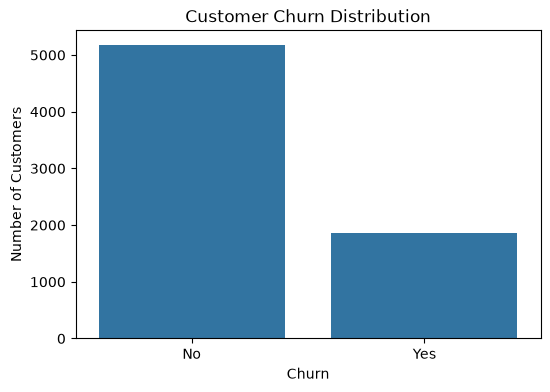

In [110]:
# Create a figure with a width of 6 inches and height of 4 inches
plt.figure(figsize=(6, 4))

# Create a count plot to show the number of customers in each churn category
sns.countplot(data=df, x="Churn")

# Add a title to the chart
plt.title("Customer Churn Distribution")

# Label the X-axis
plt.xlabel("Churn")

# Label the Y-axis
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

In [111]:
#Are customers on certain contract types more likely to leave?

# 1) Calculate churn rate by contract
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


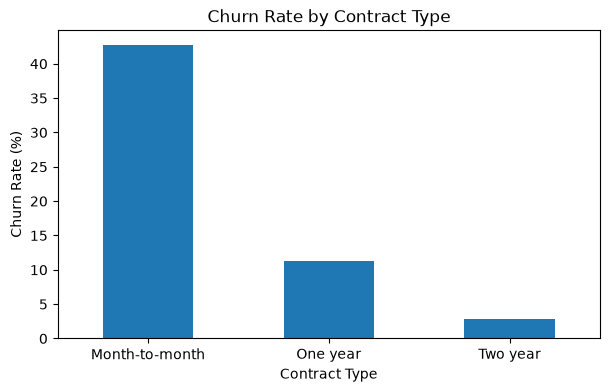

In [112]:
#create a chart specifically showing the churn percentage

contract_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../output/figures/churn_rate_by_contract.png", dpi=300, bbox_inches="tight")

plt.show()



In [113]:
# 2) Does tenure affect churn?

# Compare the tenure of customers who churned vs. customers who stayed
df.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn,,,,
No,37.569965,38.0,0,72
Yes,17.979133,10.0,1,72


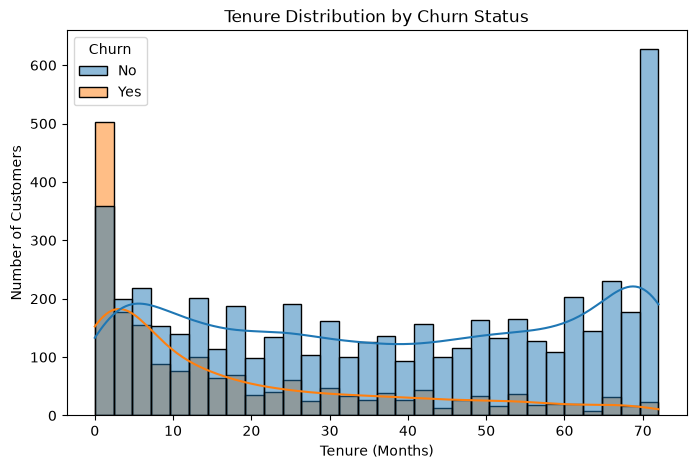

In [114]:
#Visualize tenure

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [115]:
#Does Monthly Charge affect churn?

df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn,,,,
No,61.265124,64.425,18.25,118.75
Yes,74.441332,79.650,18.85,118.35


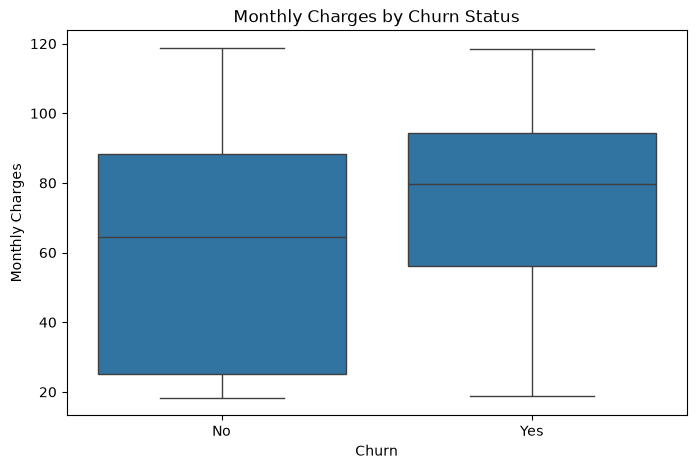

In [116]:
#VISUALISE MONTHLY CHARGE

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [117]:
#Does the type of internet service a customer uses relate to churn?

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


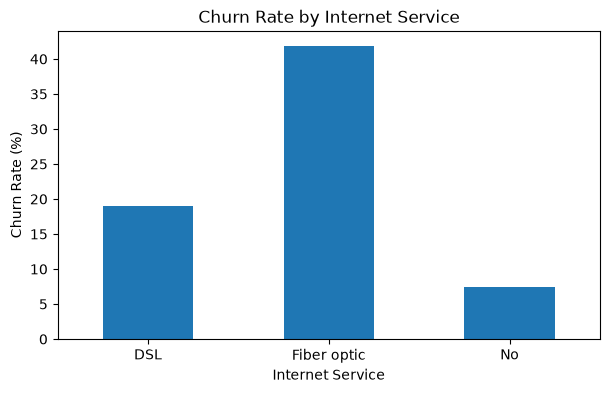

In [118]:
# Visualize churn rate by internet service type
internet_churn["Yes"].plot(kind="bar", figsize=(7, 4))

# Add chart title
plt.title("Churn Rate by Internet Service")

# Label the X-axis
plt.xlabel("Internet Service")

# Label the Y-axis
plt.ylabel("Churn Rate (%)")

# Keep category labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

In [119]:
#Does Tech Support relate to churn?

techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [120]:


#Payment Method

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

#So customers using electronic check are much more likely to churn than customers using automatic payment methods.

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


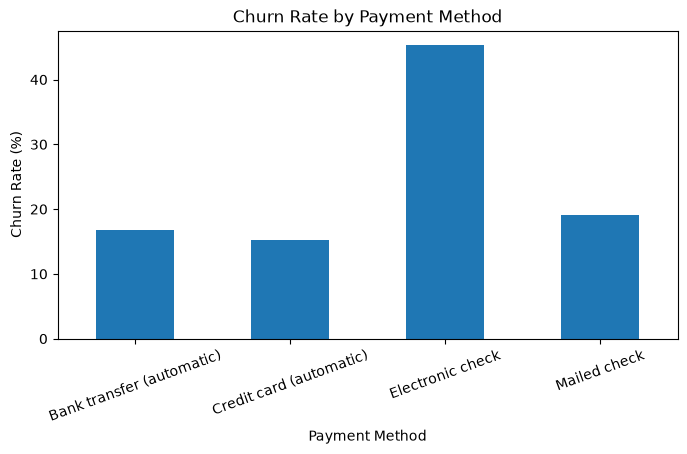

In [121]:
# Visualize churn rate by payment method
payment_churn["Yes"].plot(kind="bar", figsize=(8, 4))

# Add chart title
plt.title("Churn Rate by Payment Method")

# Label the X-axis
plt.xlabel("Payment Method")

# Label the Y-axis
plt.ylabel("Churn Rate (%)")

# Rotate labels slightly for better readability
plt.xticks(rotation=20)

# Save the chart as a high-resolution PNG file
plt.savefig(
    "../output/figures/churn_rate_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

## 5. Statistical Analysis

Statistical tests are used to determine whether the observed relationships between customer characteristics and churn are statistically significant.

In [122]:
# Statistical test: Check whether Contract Type and Churn are related

# Create a contingency table showing Contract Type vs Churn
contract_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

# Perform a Chi-square test of independence
# This checks whether the difference in churn across contract types
# is statistically significant
chi2, p_value, dof, expected = stats.chi2_contingency(contract_table)

# Display the test results
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673393e-258


In [123]:
# Statistical test: Check whether Payment Method and Churn are related

# Create a contingency table showing Payment Method vs Churn
payment_table = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

# Perform Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(payment_table)

# Display the test results
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 648.1423274814
p-value: 3.6823546520098007e-140


In [124]:
# Statistical test: Check whether Monthly Charges differ between churned and retained customers

# Select monthly charges for customers who churned
churned_charges = df[df["Churn"] == "Yes"]["MonthlyCharges"]

# Select monthly charges for customers who stayed
not_churned_charges = df[df["Churn"] == "No"]["MonthlyCharges"]

# Perform an independent two-sample t-test
# equal_var=False is used because the two groups may have different variances
t_stat, p_value = stats.ttest_ind(
    churned_charges,
    not_churned_charges,
    equal_var=False
)

# Display the test results
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 18.407526676414673
p-value: 8.592449331547065e-73


## 6. KPI Analysis

Calculate key business metrics to quantify customer retention, customer value, and the revenue impact associated with churn.

In [125]:
# KPI: Average monthly charge per customer

# Calculate the average monthly amount paid by customers
avg_monthly_charge = df["MonthlyCharges"].mean()

# Display the KPI
print("Average Monthly Charge: $", round(avg_monthly_charge, 2))

Average Monthly Charge: $ 64.76


In [126]:
# Retention rate

retention_rate = 100 - churn_rate

print("Retention Rate:", round(retention_rate, 2), "%")

Retention Rate: 73.46 %


In [127]:
# Average monthly charge

avg_monthly_charge = df["MonthlyCharges"].mean()

print("Average Monthly Charge:", round(avg_monthly_charge, 2))

Average Monthly Charge: 64.76


In [128]:
# Average customer tenure

avg_tenure = df["tenure"].mean()

print("Average Customer Tenure:", round(avg_tenure, 2), "months")

Average Customer Tenure: 32.37 months


In [129]:
# KPI: Total revenue associated with churned customers

# Select customers who have churned
churned_revenue = df[df["Churn"] == "Yes"]["TotalCharges"]

# Add their total charges
churned_revenue = churned_revenue.sum()

# Display the KPI
print("Revenue Associated with Churn: $", round(churned_revenue, 2))

Revenue Associated with Churn: $ 2862926.9


In [130]:
# Calculate the monthly charges associated with customers who churned
revenue_at_risk = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

# Display the KPI
print("Monthly Charges Associated with Churned Customers: $", round(revenue_at_risk, 2))

Monthly Charges Associated with Churned Customers: $ 139130.85


## 7. Key Business Insights & Recommendations

Based on the EDA, statistical analysis, and KPI analysis, the following findings and recommendations were identified.

In [131]:
# Churn rate by contract type

contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

# Key Business Insights

| Finding | Evidence | Business Implication |
|---|---|---|
| Month-to-month customers have the highest churn | 42.71% churn vs 11.27% for one-year and 2.83% for two-year contracts | Encourage customers to move toward longer-term contracts |
| Churn is concentrated among newer customers | Median tenure is 10 months for churned customers vs 38 months for retained customers | Focus retention efforts on customers during their first year |
| Fiber optic customers have higher churn | 41.89% churn vs 18.96% for DSL customers | Investigate pricing, service quality, and customer experience |
| Electronic check users have the highest churn | 45.29% churn rate | Investigate payment experience and encourage alternative payment methods |
| Churned customers have higher monthly charges | Median monthly charge of $79.65 vs $64.43 for retained customers | Prioritize higher-value customers in retention campaigns |
| Contract type is statistically associated with churn | Chi-square test p-value < 0.05 | Contract structure is a significant factor associated with churn |
| Payment method is statistically associated with churn | Chi-square test p-value < 0.05 | Payment method should be considered when designing retention strategies |
| Monthly charges differ significantly by churn status | t-test p-value < 0.05 | Pricing/customer value should be considered in churn analysis |

# Business Recommendations

### 1. Reduce month-to-month churn
Target month-to-month customers with retention offers and incentives to move toward one-year or two-year contracts.

### 2. Strengthen early customer retention
Focus onboarding and proactive support on customers during their first year, when churn risk is higher.

### 3. Investigate fiber optic churn
Analyze pricing, service quality, and customer experience for fiber optic customers to understand their higher churn rate.

### 4. Improve payment experience
Investigate the high churn associated with electronic check payments and encourage customers to adopt alternative payment methods.

### 5. Prioritize high-value customers
Customers with higher monthly charges represent greater potential revenue impact, so retention campaigns can prioritize these segments.

### 6. Monitor retention KPIs
Regularly track churn rate, retention rate, contract mix, tenure, and monthly charges to identify emerging churn patterns.

## 8. Correlation Analysis

In [132]:
# Convert the Churn column from text values into numerical values
# "No" = 0 means the customer did not churn
# "Yes" = 1 means the customer churned

df["Churn_Encoded"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [133]:
# Display the first 5 rows to verify that the new Churn_Encoded column was created
df[["Churn", "Churn_Encoded"]].head()

,Churn,Churn_Encoded
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [134]:
# Select the numerical variables we want to compare
correlation_data = df[
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Encoded"]
]

# Calculate the correlation between each pair of variables
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
correlation_matrix

,tenure,MonthlyCharges,TotalCharges,Churn_Encoded
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn_Encoded,-0.352229,0.193356,-0.198324,1.000000


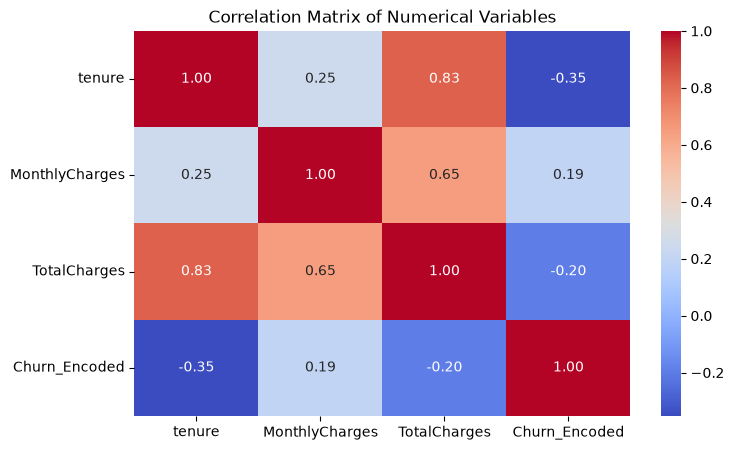

In [135]:
# Create a figure for the correlation heatmap
plt.figure(figsize=(8, 5))

# Display the correlation values using colors
# annot=True shows the numerical correlation values
# fmt=".2f" displays values up to 2 decimal places
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Add a title to the heatmap
plt.title("Correlation Matrix of Numerical Variables")

# Display the heatmap
plt.show()

## 9. Logistic Regression — Churn Prediction

In [136]:
# Select the customer features that will be used to predict churn
X = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService",
        "PaymentMethod",
        "TechSupport",
        "OnlineSecurity",
        "SeniorCitizen"
    ]
]

# Define Churn as the target variable we want to predict
# "No" = 0 and "Yes" = 1
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [137]:
# Display the first 5 rows of the selected features
X.head()

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,TechSupport,OnlineSecurity,SeniorCitizen
0,1,29.85,29.85,Month-to-month,DSL,Electronic check,No,No,0
1,34,56.95,1889.50,One year,DSL,Mailed check,No,Yes,0
2,2,53.85,108.15,Month-to-month,DSL,Mailed check,No,Yes,0
3,45,42.30,1840.75,One year,DSL,Bank transfer (automatic),Yes,Yes,0
4,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,No,No,0


In [138]:
# Convert categorical columns into numerical columns using one-hot encoding
# This creates a separate 0/1 column for each category
X_encoded = pd.get_dummies(
    X,
    columns=[
        "Contract",
        "InternetService",
        "PaymentMethod",
        "TechSupport",
        "OnlineSecurity"
    ],
    drop_first=True
)

# Display the first 5 rows of the transformed features
X_encoded.head()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TechSupport_No internet service,TechSupport_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes
0,1,29.85,29.85,0,False,False,False,False,False,True,False,False,False,False,False
1,34,56.95,1889.50,0,True,False,False,False,False,False,True,False,False,False,True
2,2,53.85,108.15,0,False,False,False,False,False,False,True,False,False,False,True
3,45,42.30,1840.75,0,True,False,False,False,False,False,False,False,True,False,True
4,2,70.70,151.65,0,False,False,True,False,False,True,False,False,False,False,False


In [139]:
# Check the number of rows and columns after one-hot encoding
# The first value is the number of customers
# The second value is the number of features used by the model
X_encoded.shape

(7043, 15)

In [140]:
# Import the function used to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the features and target into training and testing datasets
# 80% of the data will be used for training
# 20% will be used for testing
# random_state=42 makes the split reproducible
# stratify=y keeps the same churn proportion in both datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [141]:
# Display the number of rows and columns in the training features
X_train.shape


(5634, 15)

In [142]:
# Display the number of rows and columns in the testing features
X_test.shape

(1409, 15)

In [143]:
# Import the Logistic Regression algorithm
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
# max_iter=1000 gives the model enough iterations to find a solution
model = LogisticRegression(max_iter=2000)

In [144]:
# Train the Logistic Regression model using the training data
# X_train contains the customer features
# y_train contains whether each customer churned (0) or did not churn (1)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [145]:
# Use the trained model to predict whether each test customer will churn
# The model returns either 0 (No Churn) or 1 (Churn)
y_pred = model.predict(X_test)

# Display the first 10 predictions
y_pred[:10]

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0])

In [146]:
# Import the accuracy_score function from scikit-learn
from sklearn.metrics import accuracy_score

# Calculate the percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)

# Display the model's accuracy
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 79.70%


In [147]:
# Import precision, recall, and F1-score metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision
# Of the customers predicted to churn, how many actually churned?
precision = precision_score(y_test, y_pred)

# Calculate recall
# Of the customers who actually churned, how many did the model identify?
recall = recall_score(y_test, y_pred)

# Calculate F1-score
# F1-score balances precision and recall
f1 = f1_score(y_test, y_pred)

# Display all three metrics
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")

Precision: 63.92%
Recall: 54.01%
F1 Score: 58.55%


In [148]:
# Import StandardScaler to put numerical features on a similar scale
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the training data
# The scaler learns the mean and standard deviation only from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test data
X_test_scaled = scaler.transform(X_test)

In [149]:
# Create a new Logistic Regression model for the scaled features
# max_iter=2000 gives the model enough iterations to converge
improved_model = LogisticRegression(max_iter=2000)

In [150]:
# Train the improved Logistic Regression model using the scaled training data
# X_train_scaled contains the scaled customer features
# y_train contains the actual churn outcomes
improved_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [151]:
# Use the improved model to predict churn for the test customers
# 0 = predicted not to churn
# 1 = predicted to churn
y_pred_improved = improved_model.predict(X_test_scaled)

# Display the first 10 predictions
y_pred_improved[:10]

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0])

In [152]:
# Calculate the accuracy of the improved Logistic Regression model
improved_accuracy = accuracy_score(y_test, y_pred_improved)

# Display the improved model's accuracy
print(f"Improved Model Accuracy: {improved_accuracy:.2%}")

Improved Model Accuracy: 79.70%


In [153]:
# Create a Logistic Regression model that gives extra weight to churned customers
# This helps the model pay more attention to the minority churn class
balanced_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

In [154]:
# Train the balanced Logistic Regression model
# The model uses the scaled training data
# class_weight="balanced" gives more importance to churned customers
balanced_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [155]:
# Use the balanced model to predict churn for the test customers
# 0 = predicted not to churn
# 1 = predicted to churn
y_pred_balanced = balanced_model.predict(X_test_scaled)

# Display the first 10 predictions
y_pred_balanced[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1])

In [156]:
# Calculate the accuracy of the balanced Logistic Regression model
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

# Display the balanced model's accuracy
print(f"Balanced Model Accuracy: {balanced_accuracy:.2%}")

Balanced Model Accuracy: 73.74%


In [157]:
# Calculate precision for the balanced model
balanced_precision = precision_score(y_test, y_pred_balanced)

# Calculate recall for the balanced model
balanced_recall = recall_score(y_test, y_pred_balanced)

# Calculate F1-score for the balanced model
balanced_f1 = f1_score(y_test, y_pred_balanced)

# Display the three evaluation metrics
print(f"Balanced Precision: {balanced_precision:.2%}")
print(f"Balanced Recall: {balanced_recall:.2%}")
print(f"Balanced F1 Score: {balanced_f1:.2%}")

Balanced Precision: 50.33%
Balanced Recall: 80.75%
Balanced F1 Score: 62.01%


In [158]:
# Calculate the probability of churn for each test customer
# The second column contains the probability that the customer will churn
y_prob = model.predict_proba(X_test)[:, 1]

# Display the first 10 churn probabilities
y_prob[:10]

array([0.04717376, 0.57701579, 0.07138753, 0.51254361, 0.01697287,
       0.52419405, 0.42795048, 0.09841417, 0.00378869, 0.44958368])

In [159]:
# Split the training data into a smaller training set and a validation set
# The validation set will help us choose the best prediction threshold
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Display the sizes of the new training and validation sets
print("Training set:", X_train_new.shape)
print("Validation set:", X_val.shape)

Training set: (4507, 15)
Validation set: (1127, 15)


In [160]:
# Create a new Logistic Regression model for threshold tuning
validation_model = LogisticRegression(max_iter=2000)

# Train the model using only the new training set
validation_model.fit(X_train_new, y_train_new)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [161]:
# Calculate the probability of churn for each validation customer
# [:, 1] selects the probability of the "Churn = 1" class
y_val_prob = validation_model.predict_proba(X_val)[:, 1]

# Display the first 10 churn probabilities
y_val_prob[:10]

array([0.31802069, 0.01520734, 0.06499359, 0.207556  , 0.29704633,
       0.05671105, 0.08527216, 0.02121815, 0.01571749, 0.19035957])

In [162]:
# Import NumPy for numerical operations
import numpy as np

# Test several probability thresholds
thresholds = np.arange(0.30, 0.71, 0.05)

# Check how precision, recall, and F1-score change at each threshold
for threshold in thresholds:

    # Convert probabilities into 0/1 predictions using the current threshold
    y_val_pred = (y_val_prob >= threshold).astype(int)

    # Calculate evaluation metrics
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    # Display the results
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2%} | "
        f"Recall: {recall:.2%} | "
        f"F1: {f1:.2%}"
    )

Threshold: 0.30 | Precision: 53.46% | Recall: 77.59% | F1: 63.30%
Threshold: 0.35 | Precision: 57.69% | Recall: 75.25% | F1: 65.31%
Threshold: 0.40 | Precision: 60.29% | Recall: 68.56% | F1: 64.16%
Threshold: 0.45 | Precision: 63.41% | Recall: 60.87% | F1: 62.12%
Threshold: 0.50 | Precision: 68.33% | Recall: 54.85% | F1: 60.85%
Threshold: 0.55 | Precision: 72.59% | Recall: 47.83% | F1: 57.66%
Threshold: 0.60 | Precision: 74.32% | Recall: 36.79% | F1: 49.22%
Threshold: 0.65 | Precision: 75.27% | Recall: 23.41% | F1: 35.71%
Threshold: 0.70 | Precision: 79.25% | Recall: 14.05% | F1: 23.86%


In [163]:
# Apply the selected 0.35 probability threshold to the final test data
# Customers with a churn probability of 35% or more are classified as churners
y_test_pred_threshold = (y_prob >= 0.35).astype(int)

# Display the first 10 predictions
y_test_pred_threshold[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1])

In [164]:
# Calculate the final evaluation metrics using the 0.35 threshold
# Precision tells us how many predicted churners actually churned
precision_threshold = precision_score(y_test, y_test_pred_threshold)

# Recall tells us how many actual churners the model successfully identified
recall_threshold = recall_score(y_test, y_test_pred_threshold)

# F1-score balances precision and recall
f1_threshold = f1_score(y_test, y_test_pred_threshold)

# Accuracy shows the overall percentage of correct predictions
accuracy_threshold = accuracy_score(y_test, y_test_pred_threshold)

# Display the final results
print(f"Accuracy: {accuracy_threshold:.2%}")
print(f"Precision: {precision_threshold:.2%}")
print(f"Recall: {recall_threshold:.2%}")
print(f"F1 Score: {f1_threshold:.2%}")

Accuracy: 77.15%
Precision: 55.31%
Recall: 72.46%
F1 Score: 62.73%


In [165]:
# Import the confusion matrix function
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix using the final 0.35 threshold
cm = confusion_matrix(y_test, y_test_pred_threshold)

# Display the confusion matrix
print(cm)

[[816 219]
 [103 271]]


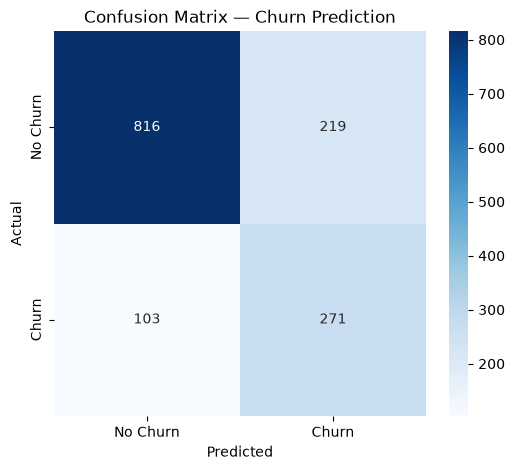

In [166]:
# Create a figure for the confusion matrix
plt.figure(figsize=(6, 5))

# Display the confusion matrix as a heatmap
# annot=True shows the number of customers in each category
# fmt="d" displays the values as whole numbers
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

# Label the axes
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add a title
plt.title("Confusion Matrix — Churn Prediction")

# Display the plot
plt.show()

In [167]:
# Create a DataFrame containing each feature and its logistic regression coefficient
# A positive coefficient means the feature increases predicted churn probability
# A negative coefficient means the feature decreases predicted churn probability
feature_coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_[0]
})

# Sort features by their coefficient from highest to lowest
# The largest positive values are the strongest churn drivers
feature_coefficients = feature_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

# Display the feature coefficients
feature_coefficients

,Feature,Coefficient
6,InternetService_Fiber optic,0.577528
9,PaymentMethod_Electronic check,0.439079
3,SeniorCitizen,0.244871
10,PaymentMethod_Mailed check,0.014563
1,MonthlyCharges,0.005737
2,TotalCharges,0.000278
8,PaymentMethod_Credit card (automatic),-0.038786
0,tenure,-0.052294
7,InternetService_No,-0.324371
11,TechSupport_No internet service,-0.324371


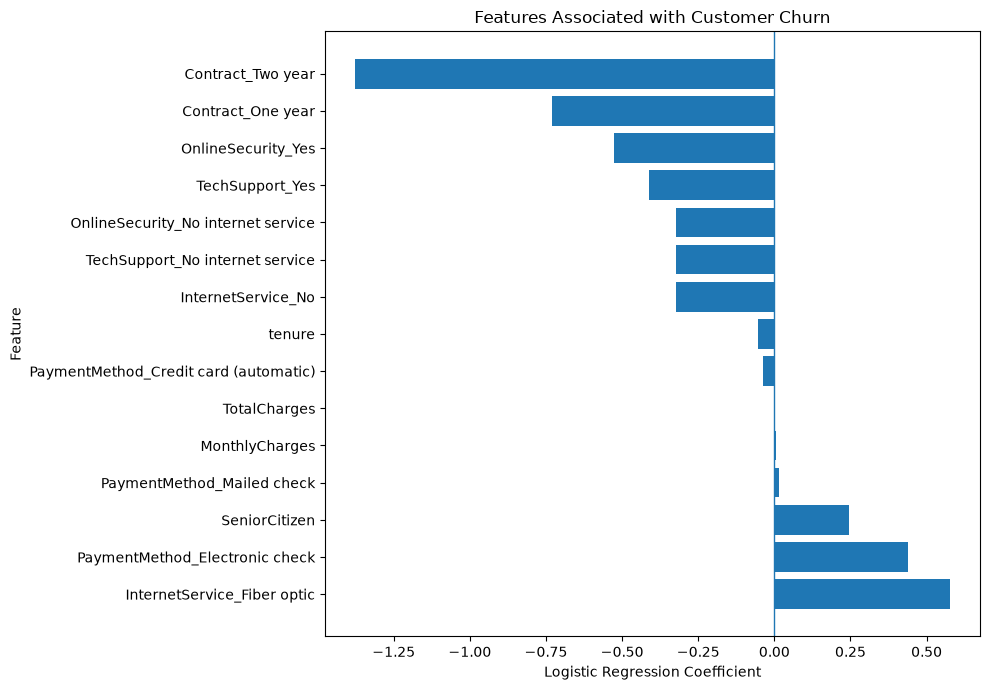

In [168]:
# Create a horizontal bar chart of logistic regression coefficients
plt.figure(figsize=(10, 7))

# Plot each feature's coefficient
# Positive values indicate higher predicted churn
# Negative values indicate lower predicted churn
plt.barh(
    feature_coefficients["Feature"],
    feature_coefficients["Coefficient"]
)

# Add a vertical reference line at zero
# This separates positive and negative associations
plt.axvline(0, linewidth=1)

# Add labels and title
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Features Associated with Customer Churn")

# Adjust the layout so feature names are not cut off
plt.tight_layout()

# Display the chart
plt.show()

In [169]:
# Create a copy of the test dataset so we can attach predictions to customers
risk_data = df.loc[X_test.index].copy()

# Add the model's predicted probability of churn
# This gives each customer a probability between 0 and 1
risk_data["Churn_Probability"] = y_prob

# Convert probabilities into practical customer risk categories
# Less than 35% = Low Risk
# 35% to 60% = Medium Risk
# More than 60% = High Risk
risk_data["Risk_Category"] = pd.cut(
    risk_data["Churn_Probability"],
    bins=[-float("inf"), 0.35, 0.60, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Display the first 10 customers with their churn probability and risk category
risk_data[
    ["customerID", "Churn_Probability", "Risk_Category"]
].head(10)

,customerID,Churn_Probability,Risk_Category
437,4376-KFVRS,0.047174,Low Risk
2280,2754-SDJRD,0.577016,Medium Risk
2235,9917-KWRBE,0.071388,Low Risk
4460,0365-GXEZS,0.512544,Medium Risk
3761,9385-NXKDA,0.016973,Low Risk
5748,4686-UXDML,0.524194,Medium Risk
3568,2227-JRSJX,0.427950,Medium Risk
2976,4830-FAXFM,0.098414,Low Risk
5928,1830-IPXVJ,0.003789,Low Risk
1639,4690-LLKUA,0.449584,Medium Risk


In [170]:
# Count how many customers fall into each churn risk category
risk_counts = risk_data["Risk_Category"].value_counts()

# Display the number of customers in each risk category
risk_counts

Risk_Category
Low Risk       919
Medium Risk    287
High Risk      203
Name: count, dtype: int64

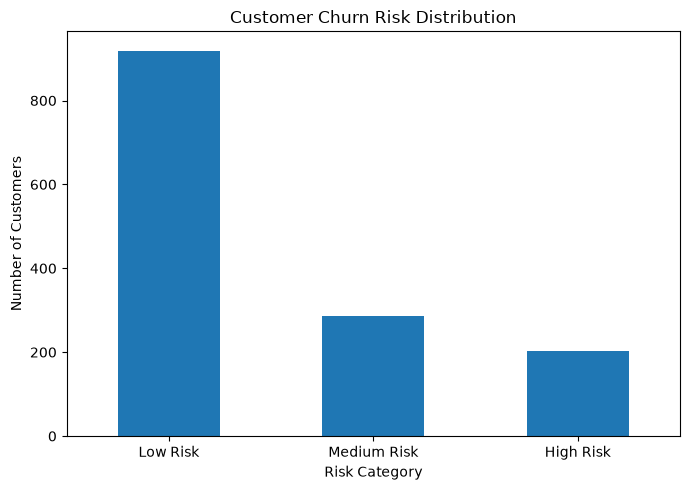

In [171]:
# Count customers in each risk category
risk_counts = risk_data["Risk_Category"].value_counts()

# Create a bar chart showing the customer risk distribution
plt.figure(figsize=(7, 5))

# Plot the number of customers in each risk category
risk_counts.plot(kind="bar")

# Add labels and title
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Risk Distribution")

# Rotate category labels for better readability
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

## 10. Final Business Insights & Recommendations

### Key Insights

1. **Contract type is the strongest churn-related factor**
   - Month-to-month customers have substantially higher churn than customers on one-year or two-year contracts.
   - The logistic regression model also shows strong negative coefficients for one-year and two-year contracts, indicating lower predicted churn compared with the reference contract category.

2. **Fiber optic customers show elevated churn risk**
   - Fiber optic customers have a higher churn rate than DSL customers.
   - The logistic regression model also identifies Fiber optic service as one of the strongest positive churn-related features.

3. **Electronic check users are more likely to churn**
   - Customers using electronic checks show a notably higher churn rate.
   - The logistic regression model also assigns a positive coefficient to electronic check payments.

4. **Newer customers are more vulnerable to churn**
   - Churned customers have substantially lower median tenure than retained customers.
   - Tenure also has a negative correlation with churn, indicating that longer-tenure customers tend to have lower churn rates.

5. **Higher monthly charges are associated with higher churn**
   - Churned customers have higher median monthly charges than retained customers.
   - This suggests that pricing and perceived value may be important areas for retention strategies.

6. **The model can identify customers who may require intervention**
   - Using a 35% churn-probability threshold, the model achieved:
     - Accuracy: 77.15%
     - Precision: 55.31%
     - Recall: 72.46%
     - F1 Score: 62.73%
   - The model classified 203 customers as High Risk and 287 as Medium Risk in the test dataset.

### Business Recommendations

- Encourage month-to-month customers to move to longer-term contracts through suitable discounts or incentives.
- Investigate pricing and service-quality concerns among high-risk Fiber optic customers.
- Encourage customers using electronic checks to adopt alternative payment methods where appropriate.
- Create targeted onboarding and engagement programs for newer customers.
- Prioritize retention campaigns for customers identified as High Risk by the predictive model.
- Use churn probabilities as a prioritization tool rather than treating predictions as certain outcomes.

### Overall Conclusion

The analysis combines exploratory data analysis, statistical testing, correlation analysis, and logistic regression to identify important churn patterns and predict customers at higher risk of leaving.

The results suggest that **contract type, internet service, payment method, tenure, and monthly charges** are important factors associated with customer churn. The predictive model provides a practical way to identify potentially at-risk customers and support targeted retention strategies.